In [1]:
import scanpy as sc

In [2]:
import scanpy as sc
import anndata as ad
from pathlib import Path
import gc
folder = Path("./mintflow_runs/run1_tiger/")

# get only epoch 5 files
files = sorted(folder.glob("adata_epoch_7_tissuesection_*.h5ad"))

# read them
adatas = [sc.read_h5ad(f) for f in files]

# concatenate
gt = ad.concat(adatas, join="outer", label="tissue_section", keys=[f.stem for f in files])
gc.collect()
print(gt)

AnnData object with n_obs × n_vars = 898364 × 4951
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'xenium_id', 'xenium_id_recoded', 'Site_status', 'GSTT patient ID', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Sample ID', 'Xenium slide number', 'Xenium region number2', 'baseline_postrx', 'info_id', 'Annotation', 'NICHE_NAMES', 'batch', 'DonorID', 'leiden_res1', 'leiden_res2', 'new_annotation', 'new_annotation2', 'new_annotation3', 'annotation_new4', 'new_annotation4', 'new_annotation5', 'new_annotation6', 'sample', 'niche_

In [3]:
gt_sub = gt[gt.obs['Sanger patient ID'].isin(['BK23', 'BK25', 'BK30'])].copy()

In [4]:
gt_sub = gt_sub[gt_sub.obs['Timepoint'].isin(['Lesional Baseline','Week 12'])].copy()

In [5]:
gt_sub = gt_sub[gt_sub.obs['Site_status'].isin(['Lesional','Week 12'])].copy()

In [6]:
gt_sub = gt_sub[gt_sub.obs['disease_overall'].isin(['AD'])].copy()
gt_sub = gt_sub[gt_sub.obs['Responder'].isin(['Responder'])].copy()

In [7]:
sc.pp.normalize_total(gt_sub)
sc.pp.log1p(gt_sub)

In [286]:
# base_dir = "/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_gene_programm/"

In [8]:
adata1=sc.read('/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_gene_programm/BK23_Lesional_Baseline/adata_with_and_without_guidance.h5ad')
adata2=sc.read('/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_gene_programm/BK25_Lesional_Baseline/adata_with_and_without_guidance.h5ad')
adata3=sc.read('/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_gene_programm/BK30_Lesional_Baseline/adata_with_and_without_guidance.h5ad')
adata = adata1.concatenate(adata2,adata3)
adata = adata[adata.obs['Timepoint'].isin(['Lesional Baseline'])].copy()
adata.obs = adata.obs.rename(columns={'gene guidance': 'perturbation'})
adata.obs['perturbation'] = adata.obs['perturbation'].cat.rename_categories({
        'gene guidance: False': 'control',
        'gene guidance: True': 'perturbed'
    })
adata.obs["perturbation"] = adata.obs["perturbation"].astype(str).astype("category")

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_3179685/3892890987.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: h

In [9]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [10]:
# 1. Rename the column
adata.obs = adata.obs.rename(columns={'gene guidance': 'perturbation'})

# 2. Rename categories
adata.obs['perturbation'] = adata.obs['perturbation'].cat.rename_categories({
    'gene guidance: False': 'control',
    'gene guidance: True': 'perturbed'
})

In [11]:
# adata already has "perturbed" / "control"

# map gt_sub labels
gt_sub.obs["condition"] = gt_sub.obs["Timepoint"].map({
    "Lesional Baseline": "control",
    "Week 12": "perturbed"
})

adata.obs["condition"] = adata.obs["perturbation"]  

In [12]:
import scanpy as sc
import pandas as pd
import numpy as np
import os

# -----------------------------
# Config
# -----------------------------
patients = [
   'BK23', 'BK25', 'BK30'
]

base_dir = "/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_gene_programm/"

valid_patients = [
   'BK23', 'BK25', 'BK30'
]

print_patients = {'BK23', 'BK25', 'BK30'}

# -----------------------------
# Helper: directionality
# -----------------------------
def directionality_accuracy_from_gt(gt_top_df, pred_fc_dict):
    n_total = len(gt_top_df)
    n_found = 0
    n_correct = 0

    for _, row in gt_top_df.iterrows():
        gene = row["names"]
        gt_logfc = row["logfoldchanges"]

        if gene not in pred_fc_dict:
            continue

        pred_logfc = pred_fc_dict[gene]
        n_found += 1

        if np.sign(gt_logfc) == np.sign(pred_logfc):
            n_correct += 1

    acc_conditional = n_correct / n_found if n_found > 0 else np.nan
    acc_overall     = n_correct / n_total if n_total > 0 else np.nan
    coverage        = n_found  / n_total  if n_total > 0 else np.nan

    return acc_conditional, acc_overall, coverage, n_found, n_correct


# -----------------------------
# Main loop
# -----------------------------
all_results = []

for patient in patients:

    if patient not in valid_patients:
        print(f"Skipping {patient} (no predictions)")
        continue

    print(f"\nProcessing {patient}")

    # -----------------------------
    # 1) GT subset
    # -----------------------------
    gt_sub = gt[gt.obs['Sanger patient ID'] == patient].copy()

    if gt_sub.n_obs == 0:
        print(f"No GT cells for {patient}")
        continue

    gt_sub = gt_sub[gt_sub.obs['Timepoint'].isin(['Lesional Baseline','Week 12'])].copy()
    gt_sub = gt_sub[gt_sub.obs['disease_overall'].isin(['AD'])].copy()
    gt_sub = gt_sub[gt_sub.obs['Responder'].isin(['Responder'])].copy()

    if gt_sub.n_obs == 0:
        print(f"No valid timepoints for {patient}")
        continue

    sc.pp.normalize_total(gt_sub)
    sc.pp.log1p(gt_sub)

    # -----------------------------
    # 2) GT DEGs
    # -----------------------------
    gt_sub.obs["Timepoint"] = gt_sub.obs["Timepoint"].astype("category")
    timepoints = gt_sub.obs["Timepoint"].unique().tolist()

    if not all(tp in timepoints for tp in ["Week 12", "Lesional Baseline"]):
        print(f"Skipping {patient} — missing required timepoints: {timepoints}")
        continue

    counts = gt_sub.obs["Timepoint"].value_counts()
    if (counts < 2).any():
        print(f"Skipping {patient} — not enough cells per group:\n{counts}")
        continue

    sc.tl.rank_genes_groups(
        gt_sub,
        groupby="Timepoint",
        groups=["Week 12"],
        reference="Lesional Baseline",
        method="wilcoxon",
    )

    deg_gt = sc.get.rank_genes_groups_df(gt_sub, group="Week 12").copy()

    deg_gt_filt = deg_gt[
        (deg_gt["pvals_adj"] < 0.05) &
        (np.abs(deg_gt["logfoldchanges"]) > 0.5)
    ].copy()

    deg_gt_filt = deg_gt_filt.sort_values(
        by="logfoldchanges",
        key=lambda x: np.abs(x),
        ascending=False
    ).reset_index(drop=True)

    top100 = deg_gt_filt.head(100)

    # -----------------------------
    # 3) Load prediction adata
    # -----------------------------
    pred_path = os.path.join(
        base_dir,
        f"{patient}_Lesional_Baseline",
        "adata_with_and_without_guidance.h5ad"
    )

    if not os.path.exists(pred_path):
        print(f"Missing prediction for {patient}")
        continue

    adata = sc.read(pred_path)

    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    adata.obs = adata.obs.rename(columns={'gene guidance': 'perturbation'})
    adata.obs['perturbation'] = adata.obs['perturbation'].cat.rename_categories({
        'gene guidance: False': 'control',
        'gene guidance: True': 'perturbed'
    })
    adata.obs["perturbation"] = adata.obs["perturbation"].astype(str).astype("category")

    # -----------------------------
    # 4) Predicted DEGs
    # -----------------------------
    sc.tl.rank_genes_groups(
        adata,
        groupby="perturbation",
        groups=["perturbed"],
        reference="control",
        method="wilcoxon",
    )

    deg_pred = sc.get.rank_genes_groups_df(adata, group="perturbed").copy()
    deg_pred = deg_pred.drop_duplicates(subset="names")
    pred_fc_dict = dict(zip(deg_pred["names"], deg_pred["logfoldchanges"]))

    # -----------------------------
    # 5) Accuracy + optional gene printing
    # -----------------------------
    acc_conditional, acc_overall, coverage, n_found, n_correct = \
        directionality_accuracy_from_gt(top100, pred_fc_dict)

    all_results.append({
        "patient":         patient,
        "TopK":            100,
        "acc_conditional": acc_conditional,
        "acc_overall":     acc_overall,
        "coverage":        coverage,
        "n_total":         len(top100),
        "n_found":         n_found,
        "n_correct":       n_correct,
    })

    # Print gene-level detail for selected patients
    if patient in print_patients:
        print(f"\n{'='*60}")
        print(f"  {patient} | Top100 GT genes vs Predictions")
        print(f"{'='*60}")
        print(f"  acc_conditional={acc_conditional:.3f}  acc_overall={acc_overall:.3f}  coverage={coverage:.3f}")
        print(f"  (n_total={len(top100)}, n_found={n_found}, n_correct={n_correct})")
        print(f"\n  {'Gene':<20} {'GT_logFC':>10} {'Pred_logFC':>12} {'Found':>7} {'Correct':>9}")
        print(f"  {'-'*20} {'-'*10} {'-'*12} {'-'*7} {'-'*9}")
        for _, row in top100.iterrows():
            gene     = row["names"]
            gt_lfc   = row["logfoldchanges"]
            pred_lfc = pred_fc_dict.get(gene, None)
            found    = pred_lfc is not None
            correct  = found and (np.sign(gt_lfc) == np.sign(pred_lfc))
            pred_str = f"{pred_lfc:+.4f}" if found else "N/A"
            print(f"  {gene:<20} {gt_lfc:+10.4f} {pred_str:>12} {'Yes' if found else 'No':>7} {'✓' if correct else '✗':>9}")


# -----------------------------
# Final results
# -----------------------------
results_df = pd.DataFrame(all_results)



Processing BK23


/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK23 | Top100 GT genes vs Predictions
  acc_conditional=0.830  acc_overall=0.830  coverage=1.000
  (n_total=100, n_found=100, n_correct=83)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  SERPINB4                -4.8392      -0.4557     Yes         ✓
  DEFB4A                  -4.7682      -0.5280     Yes         ✓
  PCSK9                   -4.3120      -1.2564     Yes         ✓
  SLC5A5                  -3.8987      -0.3335     Yes         ✓
  IL36G                   -3.8272      -0.3170     Yes         ✓
  TICRR                   -3.7179      -0.2533     Yes         ✓
  CDC20                   -3.4067      -0.3323     Yes         ✓
  NEK2                    -3.3173      -1.9584     Yes         ✓
  CENPA                   -3.1986      -0.3938     Yes         ✓
  AURKA                   -3.1473      -0.7009     Yes         ✓
  AQP5                    +3.1177      +1.2015     Yes         ✓
  FOXM1    

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK25 | Top100 GT genes vs Predictions
  acc_conditional=0.740  acc_overall=0.740  coverage=1.000
  (n_total=100, n_found=100, n_correct=74)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  TGM2                    +4.2236      +1.2520     Yes         ✓
  SMOC1                   +4.1472      +0.3613     Yes         ✓
  NPY1R                   +3.7686      +0.9142     Yes         ✓
  PPP1R1B                 +3.7383      +0.3282     Yes         ✓
  CCL26                   -3.5164      -0.5353     Yes         ✓
  PLN                     +3.2662      +0.6225     Yes         ✓
  TBXA2R                  +2.9952      +1.6590     Yes         ✓
  SERPINB4                -2.9634      -0.2768     Yes         ✓
  ALOX15                  -2.8382      -0.7070     Yes         ✓
  ECRG4                   +2.7577      +0.5460     Yes         ✓
  EDIL3                   +2.7062      -0.1476     Yes         ✗
  KCNMA1   

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK30 | Top100 GT genes vs Predictions
  acc_conditional=0.640  acc_overall=0.640  coverage=1.000
  (n_total=100, n_found=100, n_correct=64)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  CCL26                   -3.9715      -0.4822     Yes         ✓
  MMP12                   -2.9429      -0.9366     Yes         ✓
  FOSL1                   -2.7664      -1.5698     Yes         ✓
  ALOX15                  -2.6585      -0.6639     Yes         ✓
  SERPINB4                -2.6095      -0.6013     Yes         ✓
  WDR72                   +2.5932      +0.0183     Yes         ✓
  NR4A1                   -2.5528      -0.1302     Yes         ✓
  MAL                     +2.4933      +0.7170     Yes         ✓
  CDA                     +2.4840      -0.6002     Yes         ✗
  GABRP                   +2.4822      +0.3462     Yes         ✓
  CPZ                     +2.3756      -1.7630     Yes         ✗
  CFTR     

In [13]:
results_df

,patient,TopK,acc_conditional,acc_overall,coverage,n_total,n_found,n_correct
0,BK23,100,0.83,0.83,1.0,100,100,83
1,BK25,100,0.74,0.74,1.0,100,100,74
2,BK30,100,0.64,0.64,1.0,100,100,64


In [14]:
import scanpy as sc
import pandas as pd
import numpy as np
import os

# -----------------------------
# Config
# -----------------------------
patients = [
   'BK23', 'BK25', 'BK30'
]

base_dir = "/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_TBP_index17/"

valid_patients = [
   'BK23', 'BK25', 'BK30'
]

print_patients = {'BK23', 'BK25', 'BK30'}

# -----------------------------
# Helper: directionality
# -----------------------------
def directionality_accuracy_from_gt(gt_top_df, pred_fc_dict):
    n_total = len(gt_top_df)
    n_found = 0
    n_correct = 0

    for _, row in gt_top_df.iterrows():
        gene = row["names"]
        gt_logfc = row["logfoldchanges"]

        if gene not in pred_fc_dict:
            continue

        pred_logfc = pred_fc_dict[gene]
        n_found += 1

        if np.sign(gt_logfc) == np.sign(pred_logfc):
            n_correct += 1

    acc_conditional = n_correct / n_found if n_found > 0 else np.nan
    acc_overall     = n_correct / n_total if n_total > 0 else np.nan
    coverage        = n_found  / n_total  if n_total > 0 else np.nan

    return acc_conditional, acc_overall, coverage, n_found, n_correct


# -----------------------------
# Main loop
# -----------------------------
all_results = []

for patient in patients:

    if patient not in valid_patients:
        print(f"Skipping {patient} (no predictions)")
        continue

    print(f"\nProcessing {patient}")

    # -----------------------------
    # 1) GT subset
    # -----------------------------
    gt_sub = gt[gt.obs['Sanger patient ID'] == patient].copy()

    if gt_sub.n_obs == 0:
        print(f"No GT cells for {patient}")
        continue

    gt_sub = gt_sub[gt_sub.obs['Timepoint'].isin(['Lesional Baseline','Week 12'])].copy()
    gt_sub = gt_sub[gt_sub.obs['disease_overall'].isin(['AD'])].copy()
    gt_sub = gt_sub[gt_sub.obs['Responder'].isin(['Responder'])].copy()

    if gt_sub.n_obs == 0:
        print(f"No valid timepoints for {patient}")
        continue

    sc.pp.normalize_total(gt_sub)
    sc.pp.log1p(gt_sub)

    # -----------------------------
    # 2) GT DEGs
    # -----------------------------
    gt_sub.obs["Timepoint"] = gt_sub.obs["Timepoint"].astype("category")
    timepoints = gt_sub.obs["Timepoint"].unique().tolist()

    if not all(tp in timepoints for tp in ["Week 12", "Lesional Baseline"]):
        print(f"Skipping {patient} — missing required timepoints: {timepoints}")
        continue

    counts = gt_sub.obs["Timepoint"].value_counts()
    if (counts < 2).any():
        print(f"Skipping {patient} — not enough cells per group:\n{counts}")
        continue

    sc.tl.rank_genes_groups(
        gt_sub,
        groupby="Timepoint",
        groups=["Week 12"],
        reference="Lesional Baseline",
        method="wilcoxon",
    )

    deg_gt = sc.get.rank_genes_groups_df(gt_sub, group="Week 12").copy()

    deg_gt_filt = deg_gt[
        (deg_gt["pvals_adj"] < 0.05) &
        (np.abs(deg_gt["logfoldchanges"]) > 0.5)
    ].copy()

    deg_gt_filt = deg_gt_filt.sort_values(
        by="logfoldchanges",
        key=lambda x: np.abs(x),
        ascending=False
    ).reset_index(drop=True)

    top100 = deg_gt_filt.head(100)

    # -----------------------------
    # 3) Load prediction adata
    # -----------------------------
    pred_path = os.path.join(
        base_dir,
        f"{patient}_Lesional_Baseline",
        "adata_with_and_without_guidance.h5ad"
    )

    if not os.path.exists(pred_path):
        print(f"Missing prediction for {patient}")
        continue

    adata = sc.read(pred_path)

    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    adata.obs = adata.obs.rename(columns={'gene guidance': 'perturbation'})
    adata.obs['perturbation'] = adata.obs['perturbation'].cat.rename_categories({
        'gene guidance: False': 'control',
        'gene guidance: True': 'perturbed'
    })
    adata.obs["perturbation"] = adata.obs["perturbation"].astype(str).astype("category")

    # -----------------------------
    # 4) Predicted DEGs
    # -----------------------------
    sc.tl.rank_genes_groups(
        adata,
        groupby="perturbation",
        groups=["perturbed"],
        reference="control",
        method="wilcoxon",
    )

    deg_pred = sc.get.rank_genes_groups_df(adata, group="perturbed").copy()
    deg_pred = deg_pred.drop_duplicates(subset="names")
    pred_fc_dict = dict(zip(deg_pred["names"], deg_pred["logfoldchanges"]))

    # -----------------------------
    # 5) Accuracy + optional gene printing
    # -----------------------------
    acc_conditional, acc_overall, coverage, n_found, n_correct = \
        directionality_accuracy_from_gt(top100, pred_fc_dict)

    all_results.append({
        "patient":         patient,
        "TopK":            100,
        "acc_conditional": acc_conditional,
        "acc_overall":     acc_overall,
        "coverage":        coverage,
        "n_total":         len(top100),
        "n_found":         n_found,
        "n_correct":       n_correct,
    })

    # Print gene-level detail for selected patients
    if patient in print_patients:
        print(f"\n{'='*60}")
        print(f"  {patient} | Top100 GT genes vs Predictions")
        print(f"{'='*60}")
        print(f"  acc_conditional={acc_conditional:.3f}  acc_overall={acc_overall:.3f}  coverage={coverage:.3f}")
        print(f"  (n_total={len(top100)}, n_found={n_found}, n_correct={n_correct})")
        print(f"\n  {'Gene':<20} {'GT_logFC':>10} {'Pred_logFC':>12} {'Found':>7} {'Correct':>9}")
        print(f"  {'-'*20} {'-'*10} {'-'*12} {'-'*7} {'-'*9}")
        for _, row in top100.iterrows():
            gene     = row["names"]
            gt_lfc   = row["logfoldchanges"]
            pred_lfc = pred_fc_dict.get(gene, None)
            found    = pred_lfc is not None
            correct  = found and (np.sign(gt_lfc) == np.sign(pred_lfc))
            pred_str = f"{pred_lfc:+.4f}" if found else "N/A"
            print(f"  {gene:<20} {gt_lfc:+10.4f} {pred_str:>12} {'Yes' if found else 'No':>7} {'✓' if correct else '✗':>9}")


# -----------------------------
# Final results
# -----------------------------
results_df_housekeeping = pd.DataFrame(all_results)



Processing BK23


/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK23 | Top100 GT genes vs Predictions
  acc_conditional=0.660  acc_overall=0.660  coverage=1.000
  (n_total=100, n_found=100, n_correct=66)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  SERPINB4                -4.8392      -0.4450     Yes         ✓
  DEFB4A                  -4.7682      -0.4236     Yes         ✓
  PCSK9                   -4.3120      -0.6525     Yes         ✓
  SLC5A5                  -3.8987      -0.5896     Yes         ✓
  IL36G                   -3.8272      -0.4698     Yes         ✓
  TICRR                   -3.7179      -0.5993     Yes         ✓
  CDC20                   -3.4067      -0.5064     Yes         ✓
  NEK2                    -3.3173      -0.9439     Yes         ✓
  CENPA                   -3.1986      -0.5905     Yes         ✓
  AURKA                   -3.1473      -1.2651     Yes         ✓
  AQP5                    +3.1177      -0.7267     Yes         ✗
  FOXM1    

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK25 | Top100 GT genes vs Predictions
  acc_conditional=0.460  acc_overall=0.460  coverage=1.000
  (n_total=100, n_found=100, n_correct=46)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  TGM2                    +4.2236      +0.1625     Yes         ✓
  SMOC1                   +4.1472      -0.5825     Yes         ✗
  NPY1R                   +3.7686      -0.8483     Yes         ✗
  PPP1R1B                 +3.7383      -0.3445     Yes         ✗
  CCL26                   -3.5164      -0.4807     Yes         ✓
  PLN                     +3.2662      -0.6354     Yes         ✗
  TBXA2R                  +2.9952      +0.1413     Yes         ✓
  SERPINB4                -2.9634      -0.5464     Yes         ✓
  ALOX15                  -2.8382      -0.1844     Yes         ✓
  ECRG4                   +2.7577      -0.2362     Yes         ✗
  EDIL3                   +2.7062      -0.7375     Yes         ✗
  KCNMA1   

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK30 | Top100 GT genes vs Predictions
  acc_conditional=0.350  acc_overall=0.350  coverage=1.000
  (n_total=100, n_found=100, n_correct=35)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  CCL26                   -3.9715      -0.3871     Yes         ✓
  MMP12                   -2.9429      -0.4503     Yes         ✓
  FOSL1                   -2.7664      +0.0130     Yes         ✗
  ALOX15                  -2.6585      -0.3424     Yes         ✓
  SERPINB4                -2.6095      -0.5636     Yes         ✓
  WDR72                   +2.5932      -0.8313     Yes         ✗
  NR4A1                   -2.5528      -0.5027     Yes         ✓
  MAL                     +2.4933      -0.6075     Yes         ✗
  CDA                     +2.4840      -0.2609     Yes         ✗
  GABRP                   +2.4822      -0.7580     Yes         ✗
  CPZ                     +2.3756      -0.2272     Yes         ✗
  CFTR     

In [19]:
import scanpy as sc
import pandas as pd
import numpy as np
import os

# -----------------------------
# Config
# -----------------------------
patients = [
   'BK23', 'BK25', 'BK30'
]

base_dir = "/nfs/team361/am74/mintflow/revision/skin_perturbation/perturbation_results_gene_programm_il17signaling/"

valid_patients = [
   'BK23', 'BK25', 'BK30'
]

print_patients = {'BK23', 'BK25', 'BK30'}

# -----------------------------
# Helper: directionality
# -----------------------------
def directionality_accuracy_from_gt(gt_top_df, pred_fc_dict):
    n_total = len(gt_top_df)
    n_found = 0
    n_correct = 0

    for _, row in gt_top_df.iterrows():
        gene = row["names"]
        gt_logfc = row["logfoldchanges"]

        if gene not in pred_fc_dict:
            continue

        pred_logfc = pred_fc_dict[gene]
        n_found += 1

        if np.sign(gt_logfc) == np.sign(pred_logfc):
            n_correct += 1

    acc_conditional = n_correct / n_found if n_found > 0 else np.nan
    acc_overall     = n_correct / n_total if n_total > 0 else np.nan
    coverage        = n_found  / n_total  if n_total > 0 else np.nan

    return acc_conditional, acc_overall, coverage, n_found, n_correct


# -----------------------------
# Main loop
# -----------------------------
all_results = []

for patient in patients:

    if patient not in valid_patients:
        print(f"Skipping {patient} (no predictions)")
        continue

    print(f"\nProcessing {patient}")

    # -----------------------------
    # 1) GT subset
    # -----------------------------
    gt_sub = gt[gt.obs['Sanger patient ID'] == patient].copy()

    if gt_sub.n_obs == 0:
        print(f"No GT cells for {patient}")
        continue

    gt_sub = gt_sub[gt_sub.obs['Timepoint'].isin(['Lesional Baseline','Week 12'])].copy()
    gt_sub = gt_sub[gt_sub.obs['disease_overall'].isin(['AD'])].copy()
    gt_sub = gt_sub[gt_sub.obs['Responder'].isin(['Responder'])].copy()

    if gt_sub.n_obs == 0:
        print(f"No valid timepoints for {patient}")
        continue

    sc.pp.normalize_total(gt_sub)
    sc.pp.log1p(gt_sub)

    # -----------------------------
    # 2) GT DEGs
    # -----------------------------
    gt_sub.obs["Timepoint"] = gt_sub.obs["Timepoint"].astype("category")
    timepoints = gt_sub.obs["Timepoint"].unique().tolist()

    if not all(tp in timepoints for tp in ["Week 12", "Lesional Baseline"]):
        print(f"Skipping {patient} — missing required timepoints: {timepoints}")
        continue

    counts = gt_sub.obs["Timepoint"].value_counts()
    if (counts < 2).any():
        print(f"Skipping {patient} — not enough cells per group:\n{counts}")
        continue

    sc.tl.rank_genes_groups(
        gt_sub,
        groupby="Timepoint",
        groups=["Week 12"],
        reference="Lesional Baseline",
        method="wilcoxon",
    )

    deg_gt = sc.get.rank_genes_groups_df(gt_sub, group="Week 12").copy()

    deg_gt_filt = deg_gt[
        (deg_gt["pvals_adj"] < 0.05) &
        (np.abs(deg_gt["logfoldchanges"]) > 0.5)
    ].copy()

    deg_gt_filt = deg_gt_filt.sort_values(
        by="logfoldchanges",
        key=lambda x: np.abs(x),
        ascending=False
    ).reset_index(drop=True)

    top100 = deg_gt_filt.head(100)

    # -----------------------------
    # 3) Load prediction adata
    # -----------------------------
    pred_path = os.path.join(
        base_dir,
        f"{patient}_Lesional_Baseline",
        "adata_with_and_without_guidance.h5ad"
    )

    if not os.path.exists(pred_path):
        print(f"Missing prediction for {patient}")
        continue

    adata = sc.read(pred_path)

    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

    adata.obs = adata.obs.rename(columns={'gene guidance': 'perturbation'})
    adata.obs['perturbation'] = adata.obs['perturbation'].cat.rename_categories({
        'gene guidance: False': 'control',
        'gene guidance: True': 'perturbed'
    })
    adata.obs["perturbation"] = adata.obs["perturbation"].astype(str).astype("category")

    # -----------------------------
    # 4) Predicted DEGs
    # -----------------------------
    sc.tl.rank_genes_groups(
        adata,
        groupby="perturbation",
        groups=["perturbed"],
        reference="control",
        method="wilcoxon",
    )

    deg_pred = sc.get.rank_genes_groups_df(adata, group="perturbed").copy()
    deg_pred = deg_pred.drop_duplicates(subset="names")
    pred_fc_dict = dict(zip(deg_pred["names"], deg_pred["logfoldchanges"]))

    # -----------------------------
    # 5) Accuracy + optional gene printing
    # -----------------------------
    acc_conditional, acc_overall, coverage, n_found, n_correct = \
        directionality_accuracy_from_gt(top100, pred_fc_dict)

    all_results.append({
        "patient":         patient,
        "TopK":            100,
        "acc_conditional": acc_conditional,
        "acc_overall":     acc_overall,
        "coverage":        coverage,
        "n_total":         len(top100),
        "n_found":         n_found,
        "n_correct":       n_correct,
    })

    # Print gene-level detail for selected patients
    if patient in print_patients:
        print(f"\n{'='*60}")
        print(f"  {patient} | Top100 GT genes vs Predictions")
        print(f"{'='*60}")
        print(f"  acc_conditional={acc_conditional:.3f}  acc_overall={acc_overall:.3f}  coverage={coverage:.3f}")
        print(f"  (n_total={len(top100)}, n_found={n_found}, n_correct={n_correct})")
        print(f"\n  {'Gene':<20} {'GT_logFC':>10} {'Pred_logFC':>12} {'Found':>7} {'Correct':>9}")
        print(f"  {'-'*20} {'-'*10} {'-'*12} {'-'*7} {'-'*9}")
        for _, row in top100.iterrows():
            gene     = row["names"]
            gt_lfc   = row["logfoldchanges"]
            pred_lfc = pred_fc_dict.get(gene, None)
            found    = pred_lfc is not None
            correct  = found and (np.sign(gt_lfc) == np.sign(pred_lfc))
            pred_str = f"{pred_lfc:+.4f}" if found else "N/A"
            print(f"  {gene:<20} {gt_lfc:+10.4f} {pred_str:>12} {'Yes' if found else 'No':>7} {'✓' if correct else '✗':>9}")


# -----------------------------
# Final results
# -----------------------------
results_df_il17signaling= pd.DataFrame(all_results)



Processing BK23


/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK23 | Top100 GT genes vs Predictions
  acc_conditional=0.340  acc_overall=0.340  coverage=1.000
  (n_total=100, n_found=100, n_correct=34)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  SERPINB4                -4.8392      +0.9279     Yes         ✗
  DEFB4A                  -4.7682      +1.4369     Yes         ✗
  PCSK9                   -4.3120      -0.4190     Yes         ✓
  SLC5A5                  -3.8987      +0.6208     Yes         ✗
  IL36G                   -3.8272      +1.1401     Yes         ✗
  TICRR                   -3.7179      +0.2615     Yes         ✗
  CDC20                   -3.4067      +0.3550     Yes         ✗
  NEK2                    -3.3173      -0.6392     Yes         ✓
  CENPA                   -3.1986      +0.6016     Yes         ✗
  AURKA                   -3.1473      -1.0201     Yes         ✓
  AQP5                    +3.1177      +0.7976     Yes         ✓
  FOXM1    

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK25 | Top100 GT genes vs Predictions
  acc_conditional=0.380  acc_overall=0.380  coverage=1.000
  (n_total=100, n_found=100, n_correct=38)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  TGM2                    +4.2236      -1.2313     Yes         ✗
  SMOC1                   +4.1472      -0.4872     Yes         ✗
  NPY1R                   +3.7686      +0.8369     Yes         ✓
  PPP1R1B                 +3.7383      +0.1264     Yes         ✓
  CCL26                   -3.5164      -0.3528     Yes         ✓
  PLN                     +3.2662      +1.3399     Yes         ✓
  TBXA2R                  +2.9952      -0.5112     Yes         ✗
  SERPINB4                -2.9634      +0.9459     Yes         ✗
  ALOX15                  -2.8382      -1.3768     Yes         ✓
  ECRG4                   +2.7577      -0.0831     Yes         ✗
  EDIL3                   +2.7062      +0.6806     Yes         ✓
  KCNMA1   

/nfs/team361/aa36/PythonEnvs_2/env_Feb19th_MintFlowGenePerturbation/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



  BK30 | Top100 GT genes vs Predictions
  acc_conditional=0.390  acc_overall=0.390  coverage=1.000
  (n_total=100, n_found=100, n_correct=39)

  Gene                   GT_logFC   Pred_logFC   Found   Correct
  -------------------- ---------- ------------ ------- ---------
  CCL26                   -3.9715      -0.2044     Yes         ✓
  MMP12                   -2.9429      -1.0858     Yes         ✓
  FOSL1                   -2.7664      +0.5819     Yes         ✗
  ALOX15                  -2.6585      -1.4077     Yes         ✓
  SERPINB4                -2.6095      +0.7842     Yes         ✗
  WDR72                   +2.5932      +1.0330     Yes         ✓
  NR4A1                   -2.5528      +0.0781     Yes         ✗
  MAL                     +2.4933      -0.3613     Yes         ✗
  CDA                     +2.4840      -0.8903     Yes         ✗
  GABRP                   +2.4822      +1.0527     Yes         ✓
  CPZ                     +2.3756      -0.6233     Yes         ✗
  CFTR     

In [20]:
results_df_il17signaling

,patient,TopK,acc_conditional,acc_overall,coverage,n_total,n_found,n_correct
0,BK23,100,0.34,0.34,1.0,100,100,34
1,BK25,100,0.38,0.38,1.0,100,100,38
2,BK30,100,0.39,0.39,1.0,100,100,39


In [22]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
fm.fontManager.addfont('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/Private_emily/helvetica.ttf')

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.grid'] = False
sc.set_figure_params(dpi_save=600,fontsize=12)

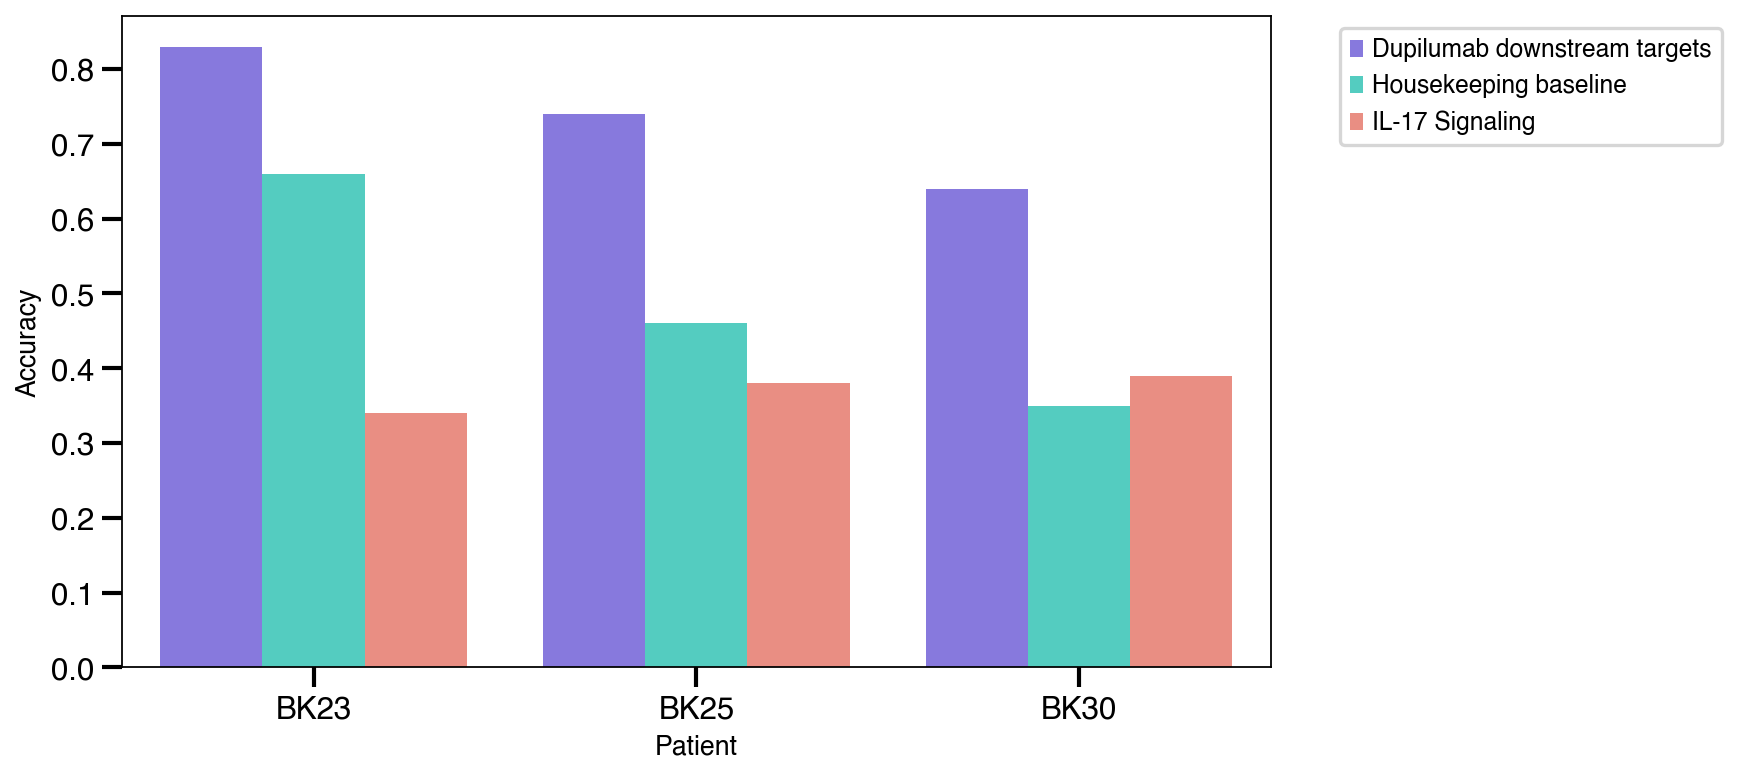

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add labels
df1 = results_df.copy()
df1["source"] = "Dupilumab downstream targets"
df2 = results_df_housekeeping.copy()
df2["source"] = "Housekeeping baseline"
df3 = results_df_il17signaling.copy()
df3["source"] = "IL-17 Signaling"

# Combine
df_all = pd.concat([df1, df2, df3], ignore_index=True)

# Custom colors
palette = {
    "Dupilumab downstream targets": "mediumslateblue",
    "Housekeeping baseline": "turquoise",
    "IL-17 Signaling": "salmon"
}

# Plot
plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_all,
    x="patient",
    y="acc_overall",
    hue="source",
    palette=palette
)
plt.ylabel("Accuracy")
plt.xlabel("Patient")
plt.xticks(rotation=0, fontsize=14)
plt.yticks(rotation=0, fontsize=14)

# Legend outside
plt.legend(title="", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)

# Leave space for legend
plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.savefig('./accuracy_per_patent.svg', dpi=600)
plt.show()

In [26]:
df_all

,patient,TopK,acc_conditional,acc_overall,coverage,n_total,n_found,n_correct,source
0,BK23,100,0.83,0.83,1.0,100,100,83,Dupilumab targets
1,BK25,100,0.74,0.74,1.0,100,100,74,Dupilumab targets
2,BK30,100,0.64,0.64,1.0,100,100,64,Dupilumab targets
3,BK23,100,0.66,0.66,1.0,100,100,66,Housekeeping baseline
4,BK25,100,0.46,0.46,1.0,100,100,46,Housekeeping baseline
5,BK30,100,0.35,0.35,1.0,100,100,35,Housekeeping baseline
6,BK23,100,0.34,0.34,1.0,100,100,34,IL-17 Signaling
7,BK25,100,0.38,0.38,1.0,100,100,38,IL-17 Signaling
8,BK30,100,0.39,0.39,1.0,100,100,39,IL-17 Signaling


/tmp/ipykernel_3179685/1375540959.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


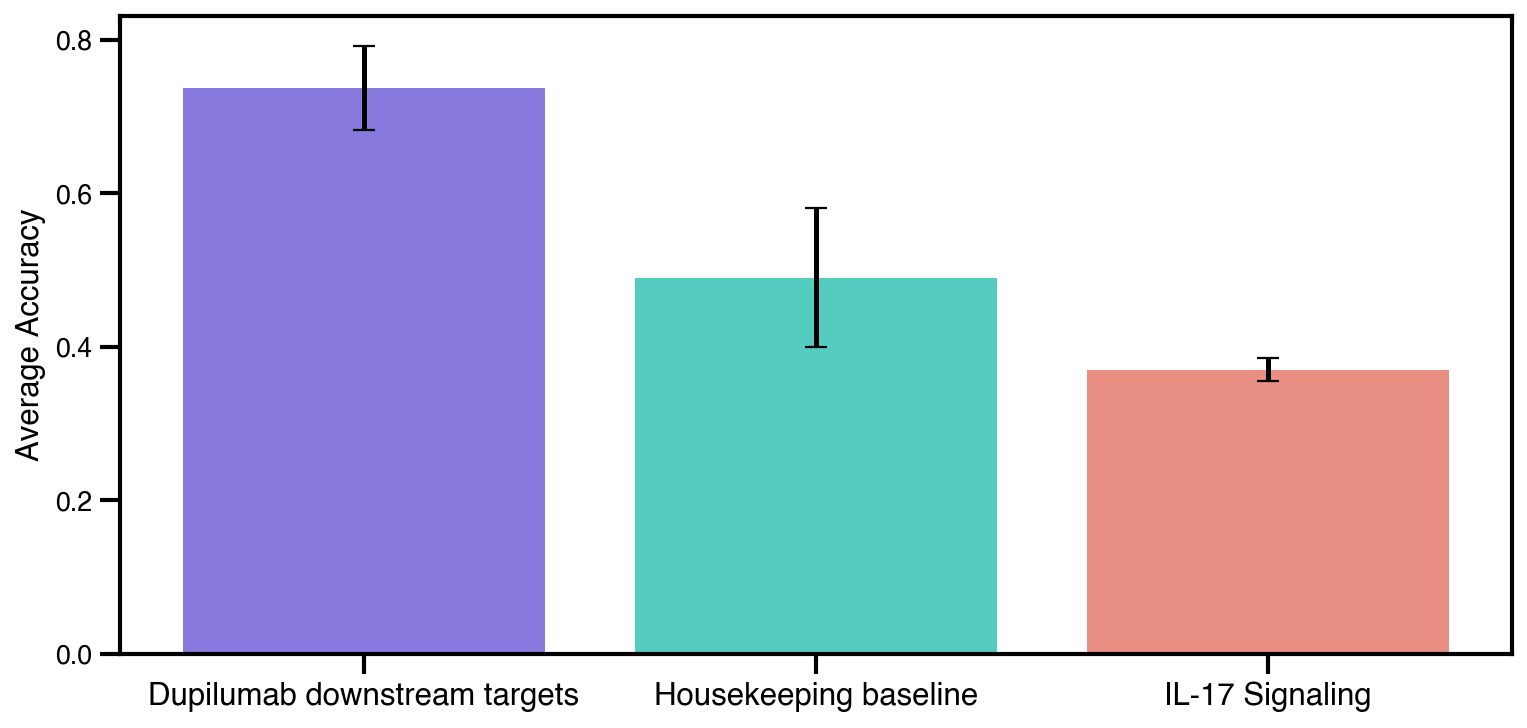

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Global font scaling
sns.set_context("talk", font_scale=1.2)

# Add labels
df1 = results_df.copy()
df1["source"] = "Dupilumab downstream targets"
df2 = results_df_housekeeping.copy()
df2["source"] = "Housekeeping baseline"
df3 = results_df_il17signaling.copy()
df3["source"] = "IL-17 Signaling"

# Combine
df_all = pd.concat([df1, df2, df3], ignore_index=True)

# Compute mean + standard error
df_stats = (
    df_all
    .groupby("source")["acc_overall"]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
df_stats["se"] = df_stats["std"] / np.sqrt(df_stats["count"])

# Colors
palette = {
    "Dupilumab downstream targets": "mediumslateblue",
    "Housekeeping baseline": "turquoise",
    "IL-17 Signaling": "salmon"
}

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_stats,
    x="source",
    y="mean",
    palette=palette,
    errorbar=None
)

# Error bars
plt.errorbar(
    x=range(len(df_stats)),
    y=df_stats["mean"],
    yerr=df_stats["se"],
    fmt='none',
    capsize=5,
    color='black'
)

# Labels
plt.ylabel("Average Accuracy", fontsize=14)
plt.xlabel("")
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('./accuracy_overall.svg', dpi=600)
plt.show()

/tmp/ipykernel_3179685/4289135189.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


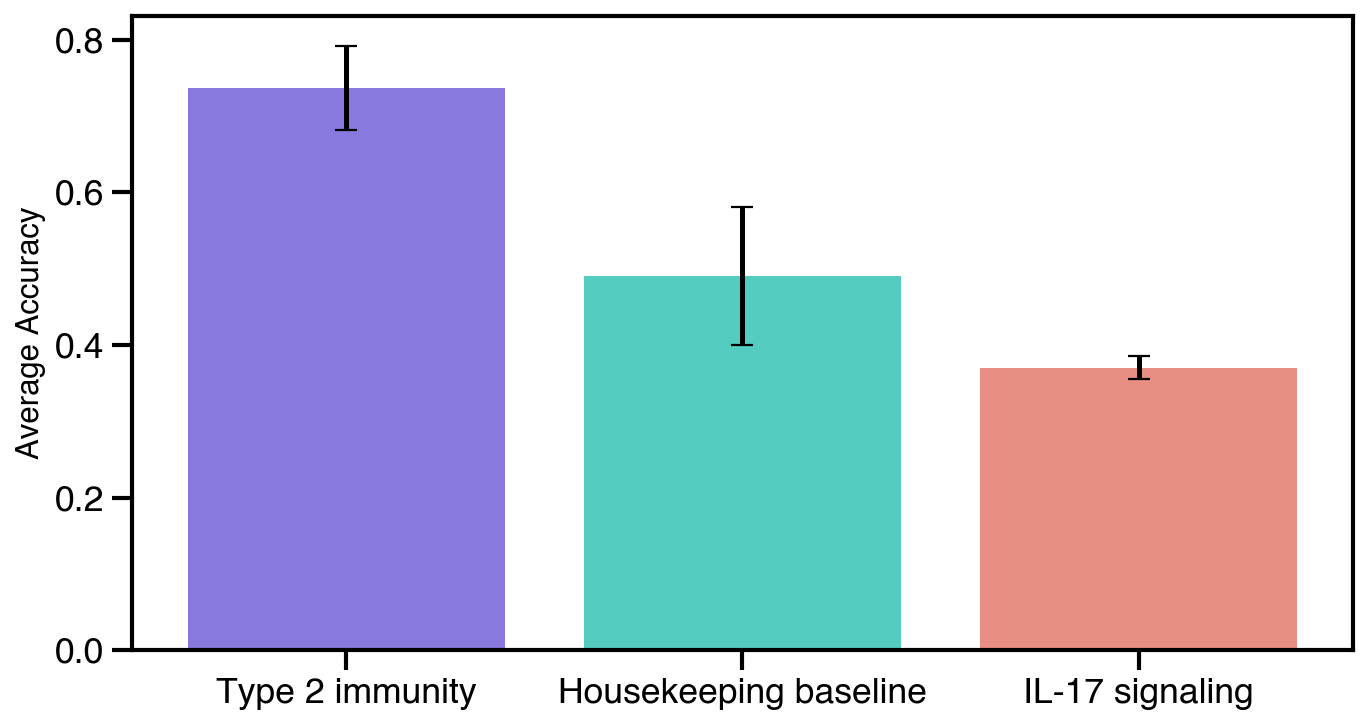

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Global font scaling
sns.set_context("talk", font_scale=1.2)

# Add labels
df1 = results_df.copy()
df1["source"] = "Type 2 immunity"
df2 = results_df_housekeeping.copy()
df2["source"] = "Housekeeping baseline"
df3 = results_df_il17signaling.copy()
df3["source"] = "IL-17 signaling"

# Combine
df_all = pd.concat([df1, df2, df3], ignore_index=True)

# Compute mean + standard error
df_stats = (
    df_all
    .groupby("source")["acc_overall"]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
df_stats["se"] = df_stats["std"] / np.sqrt(df_stats["count"])

# Colors
palette = {
    "Type 2 immunity": "mediumslateblue",
    "Housekeeping baseline": "turquoise",
    "IL-17 signaling": "salmon"
}
order = list(palette.keys())

# Reindex to match order
df_stats_ordered = df_stats.set_index("source").loc[order].reset_index()

# Plot
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_stats,
    x="source",
    y="mean",
    palette=palette,
    order=order,
    errorbar=None
)

# Error bars
plt.errorbar(
    x=range(len(df_stats_ordered)),
    y=df_stats_ordered["mean"],
    yerr=df_stats_ordered["se"],
    fmt='none',
    capsize=5,
    color='black'
)

# Labels
plt.ylabel("Average Accuracy", fontsize=14)
plt.xlabel("")
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.savefig('./accuracy_overall.svg', dpi=600)
plt.show()